# Factores desencadenantes predominantes en registros de ideación suicida

**Población:** adolescentes de 12 a 17 años en Bogotá  
**Periodo:** 2017-2025  
**Autores:** Paola Yate Cuervo y Wilber Jonatan Plazas Murcia

**Pregunta principal:** ¿Qué factores desencadenantes predominan en los registros de ideación suicida notificados en adolescentes de 12 a 17 años en Bogotá entre 2017 y 2025?

Los nueve factores analizados no son excluyentes: una misma notificación puede registrar más de un factor con valor 1. Por ello, la suma de sus proporciones puede superar el 100 %.

## 1. Configuración e importación de funciones

In [1]:
from pathlib import Path
import sys

from IPython.display import display

# Permite ejecutar el notebook desde la raíz del proyecto o desde notebooks/.
RAIZ_PROYECTO = Path.cwd()
if not (RAIZ_PROYECTO / "src").exists():
    RAIZ_PROYECTO = RAIZ_PROYECTO.parent

if str(RAIZ_PROYECTO) not in sys.path:
    sys.path.insert(0, str(RAIZ_PROYECTO))

from src.datos import (
    FACTORES, cargar_datos, seleccionar_columnas,
    filtrar_poblacion, validar_datos
)
from src.indicadores import calcular_indicadores, generar_ranking
from src.estadistica import comparar_mcnemar, prueba_cochran
from src.visualizacion import grafico_evolucion_top3, grafico_mapa_calor_anual, grafico_ranking_global

ANO_INICIAL = 2017
ANO_FINAL = 2025
RUTA_DATOS = RAIZ_PROYECTO / "data" / "osb_salud_mental_ideacion_e_intento.csv"

print(f"Periodo configurado: {ANO_INICIAL}-{ANO_FINAL}")
print(f"Archivo de datos: {RUTA_DATOS}")

Periodo configurado: 2017-2025
Archivo de datos: /workspace/scratch/037362ef714b/final_entregable.OrlonU/Proyecto_analitica_datos/data/osb_salud_mental_ideacion_e_intento.csv


## 2. Carga, selección y validación de los datos

Primero se carga la base completa y se observan sus cinco primeros registros mediante `head(5)`. Después se conservan únicamente las tres variables necesarias para el filtro y los nueve factores desencadenantes. La validación comprueba valores faltantes, codificación 0/1 y escritura exacta de las categorías utilizadas en el filtro.

In [2]:
# Se carga la base completa, con todas sus columnas.
datos = cargar_datos(RUTA_DATOS)

print(f"Dimensiones de la base completa: {datos.shape[0]} filas y {datos.shape[1]} columnas")
display(datos.head(5))

# Después de observar la fuente, se conservan solo las doce columnas necesarias.
datos_seleccionados = seleccionar_columnas(datos)

# Se revisan nulos, categorías de filtro y valores binarios antes de filtrar.
reporte_calidad = validar_datos(datos_seleccionados)
display(reporte_calidad)
print("Categorías de conducta y ciclo vital: escritura correcta.")
print("Factores desencadenantes: valores limitados a 0 y 1.")

# Finalmente se seleccionan la conducta, el ciclo vital y el periodo definidos.
datos_estudio = filtrar_poblacion(datos_seleccionados, ANO_INICIAL, ANO_FINAL)

print(f"Registros seleccionados para el análisis: {len(datos_estudio)}")

Dimensiones de la base completa: 274648 filas y 18 columnas


,ano_notificacion,codigo_localidadresidencia,localidad_residencia,nombre_upz,ciclovital,clasificaciondelaconducta,sexo,niveleducativo,enfermedades_dolorosas,maltrato_sexual,muerte_familiar,conflicto_pareja,problemas_economicos,esc_educ,problemas_juridicos,problemas_laborales,suicidio_amigo,poblacion_diferencial
0,2023,1.0,Usaquén,TOBERIN,>60 Vejez,Ideación suicida,Hombre,6. Secundaria completa,0,0,0,0,0,0,0,0,0,Ninguna
1,2025,19.0,Ciudad Bolívar,ARBORIZADORA,>60 Vejez,Ideación suicida,Mujer,6. Secundaria completa,0,0,1,0,0,0,0,0,0,Ninguna
2,2025,11.0,Suba,BRITALIA,>60 Vejez,Ideación suicida,Hombre,10. Universidad completa,0,0,0,0,0,0,0,0,0,Ninguna
3,2022,8.0,Kennedy,CALANDAIMA,>60 Vejez,Ideación suicida,Hombre,5. Secundaria incompleta,0,0,0,0,1,0,0,0,0,Ninguna
4,2024,7.0,Bosa,EL PORVENIR,>60 Vejez,Ideación suicida,Hombre,4. Primaria completa,0,0,0,0,0,0,0,0,0,Ninguna


,Valores faltantes
ano_notificacion,0
clasificaciondelaconducta,0
ciclovital,0
enfermedades_dolorosas,0
maltrato_sexual,0
muerte_familiar,0
conflicto_pareja,0
problemas_economicos,0
esc_educ,0
problemas_juridicos,0


Categorías de conducta y ciclo vital: escritura correcta.
Factores desencadenantes: valores limitados a 0 y 1.
Registros seleccionados para el análisis: 53887


## 3. Análisis descriptivo

### 3.1 Resultados globales

La frecuencia indica cuántas notificaciones presentan cada factor. La proporción se calcula sobre el total de registros filtrados del periodo.

In [3]:
resumen_global, resumen_anual, top3_anual = calcular_indicadores(datos_estudio)
numero_anos = datos_estudio["ano_notificacion"].nunique()
ranking = generar_ranking(resumen_global, top3_anual, numero_anos)

resumen_global_mostrar = resumen_global[["Factor", "Frecuencia", "Proporción"]].copy()
resumen_global_mostrar["Proporción (%)"] = (
    resumen_global_mostrar.pop("Proporción") * 100
).round(2)
display(resumen_global_mostrar)

,Factor,Frecuencia,Proporción (%)
0,Problemas escolares,27243,50.56
1,Maltrato sexual,6899,12.80
2,Conflicto de pareja,3832,7.11
3,Muerte de un familiar,2965,5.50
4,Problemas económicos,1751,3.25
5,Enfermedades dolorosas,956,1.77
6,Suicidio de un amigo,598,1.11
7,Problemas laborales,491,0.91
8,Problemas jurídicos,199,0.37


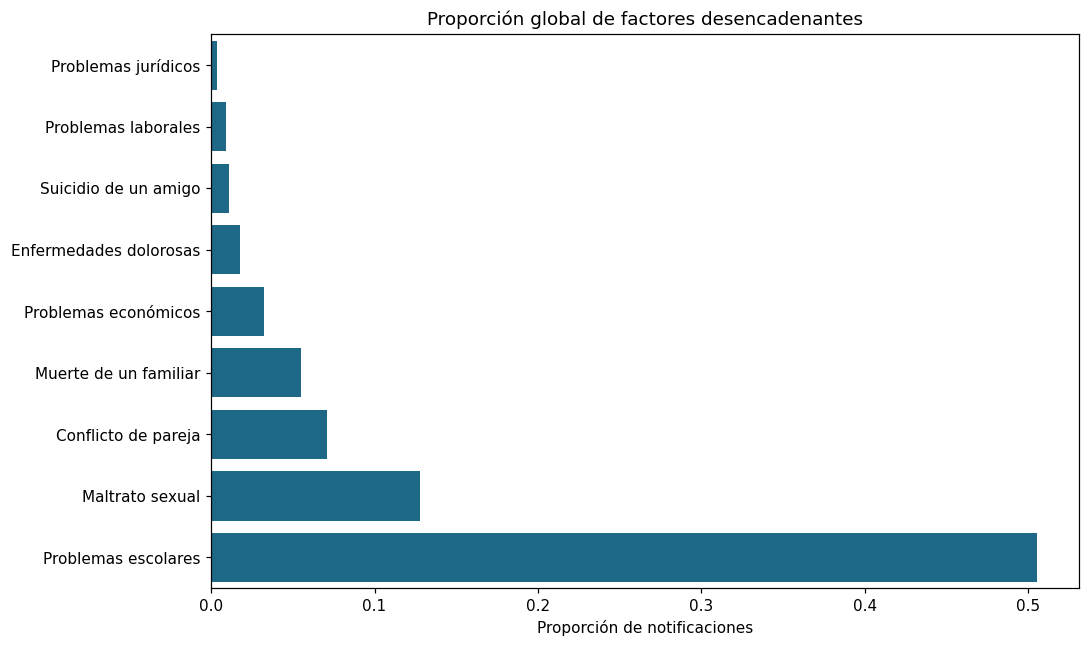

In [4]:
grafico_ranking_global(ranking)

### 3.2 Resultados anuales

La tabla presenta las frecuencias de los nueve factores y el total de registros filtrados de cada año. Para cada factor, la proporción anual se obtiene dividiendo su frecuencia entre el total de registros del mismo año. El mapa de calor representa esas proporciones.

In [5]:
tabla_frecuencias = resumen_anual.pivot(
    index="Año", columns="factor", values="Frecuencia"
)

# El total anual es el denominador utilizado para calcular las proporciones.
totales_anuales = datos_estudio.groupby("ano_notificacion").size()
tabla_frecuencias.insert(0, "Total registros", totales_anuales)
display(tabla_frecuencias)

factor,Total registros,conflicto_pareja,enfermedades_dolorosas,esc_educ,maltrato_sexual,muerte_familiar,problemas_economicos,problemas_juridicos,problemas_laborales,suicidio_amigo
Año,,,,,,,,,,
2017,2530,11,2,22,11,2,4,0,0,1
2018,3589,699,21,1044,629,116,91,8,11,44
2019,3732,266,68,2288,1216,233,121,28,5,64
2020,2947,210,83,1922,796,183,171,28,9,30
2021,5167,339,121,2938,776,354,267,29,37,52
2022,9255,449,146,5652,920,551,302,25,59,113
2023,9236,583,202,4875,868,529,298,22,111,97
2024,8746,673,171,4213,855,495,298,36,158,107
2025,8685,602,142,4289,828,502,199,23,101,90


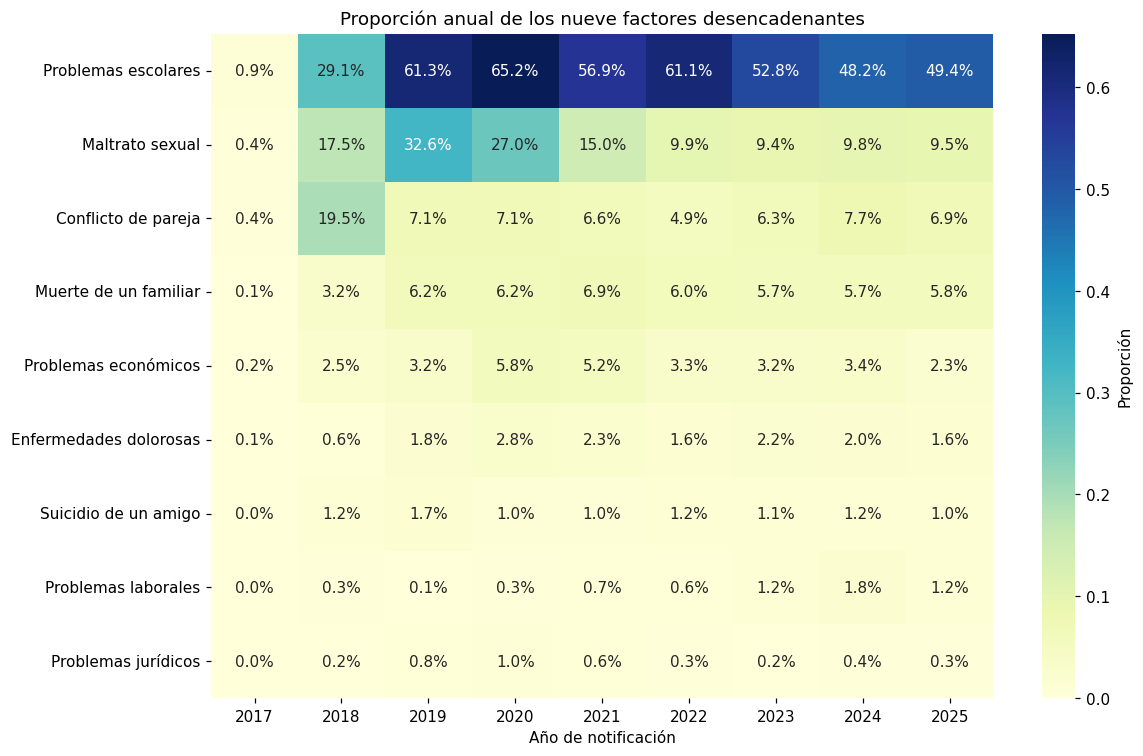

In [6]:
grafico_mapa_calor_anual(resumen_anual)

## 4. Análisis estadístico

### 4.1 Prueba Q de Cochran

Esta prueba evalúa conjuntamente los nueve factores binarios utilizando todos los registros filtrados.

- **Hipótesis nula (H₀):** los nueve factores presentan la misma proporción de registros con valor 1.
- **Hipótesis alternativa (H₁):** al menos uno de los factores presenta una proporción diferente.
- **Nivel de significancia:** α = 0,05.

In [7]:
resultado_cochran = prueba_cochran(datos_estudio, FACTORES)
display(resultado_cochran)

p_cochran = resultado_cochran.loc[0, "p-valor"]

if p_cochran < 0.05:
    print(
        "Conclusión: se rechaza H0. Existe evidencia estadística de que "
        "las proporciones de los nueve factores no son iguales."
    )
else:
    print(
        "Conclusión: no se rechaza H0. No existe evidencia estadística suficiente "
        "para afirmar que las proporciones de los nueve factores sean diferentes."
    )

,Estadístico Q,Grados de libertad,p-valor,N utilizado,Decisión
0,124083.018397,8,0.0,53887,Rechazar H0


Conclusión: se rechaza H0. Existe evidencia estadística de que las proporciones de los nueve factores no son iguales.


### 4.2 Selección de los tres factores predominantes

Después de evaluar conjuntamente los nueve factores, se seleccionan los tres predominantes según su **proporción global** y su **persistencia entre los tres primeros de cada año**. Esta selección permite enfocar la comparación posterior sin generar 36 comparaciones entre todos los factores.

In [8]:
factores_top3 = ranking.head(3)["factor"].tolist()

top3_mostrar = ranking.head(3)[
    ["Factor", "Proporción", "Años en top 3"]
].copy()
top3_mostrar["Proporción global (%)"] = (
    top3_mostrar.pop("Proporción") * 100
).round(2)
top3_mostrar["Persistencia"] = (
    top3_mostrar["Años en top 3"].astype(str)
    + " de "
    + str(numero_anos)
    + " años"
)
top3_mostrar = top3_mostrar.drop(columns="Años en top 3")
display(top3_mostrar)

,Factor,Proporción global (%),Persistencia
0,Problemas escolares,50.56,9 de 9 años
1,Maltrato sexual,12.80,9 de 9 años
2,Conflicto de pareja,7.11,7 de 9 años


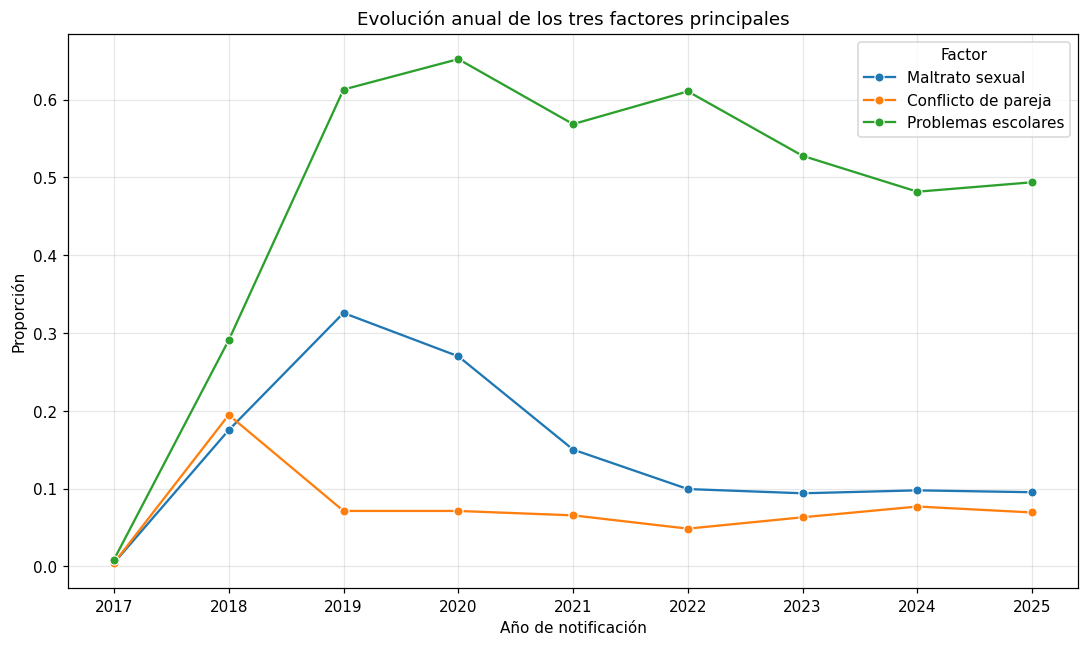

In [9]:
grafico_evolucion_top3(resumen_anual, factores_top3)

### 4.3 Prueba de McNemar

McNemar compara por parejas los tres factores predominantes seleccionados. Cada comparación utiliza todos los registros filtrados y los p-valores se ajustan mediante el método de Holm.

- **Hipótesis nula (H₀):** los dos factores comparados presentan la misma proporción de registros con valor 1.
- **Hipótesis alternativa (H₁):** los dos factores comparados presentan proporciones diferentes.
- **Nivel de significancia:** α = 0,05.

In [10]:
if p_cochran < 0.05:
    resultados_mcnemar = comparar_mcnemar(datos_estudio, factores_top3)
    display(resultados_mcnemar)

    if (resultados_mcnemar["Decisión"] == "Rechazar H0").all():
        print(
            "Conclusión: después del ajuste de Holm, se rechaza H0 en las tres "
            "comparaciones. Los tres factores predominantes presentan proporciones "
            "estadísticamente diferentes entre sí."
        )
    else:
        print(
            "Conclusión: no todas las parejas presentan diferencias estadísticamente "
            "significativas después del ajuste de Holm."
        )
else:
    print(
        "McNemar no se ejecuta porque la Q de Cochran no encontró diferencias "
        "generales entre los nueve factores."
    )

,Factor A,Factor B,Estadístico,p-valor,N utilizado,p-valor ajustado (Holm),Decisión
0,Problemas escolares,Maltrato sexual,13784.479682,0.000000e+00,53887,0.000000e+00,Rechazar H0
1,Problemas escolares,Conflicto de pareja,18847.477388,0.000000e+00,53887,0.000000e+00,Rechazar H0
2,Maltrato sexual,Conflicto de pareja,930.451945,2.355347e-204,53887,2.355347e-204,Rechazar H0


Conclusión: después del ajuste de Holm, se rechaza H0 en las tres comparaciones. Los tres factores predominantes presentan proporciones estadísticamente diferentes entre sí.


## 5. Verificación del escenario de control

El funcionamiento normal ya se comprueba mediante la ejecución completa del notebook. En este apartado se verifica únicamente el escenario de fallo definido en la propuesta: se elimina deliberadamente una columna requerida y se comprueba que la validación identifique el problema.

In [11]:
# Se elimina una variable para comprobar el control de estructura.
datos_incompletos = datos_seleccionados.drop(columns=["maltrato_sexual"])

try:
    validar_datos(datos_incompletos)
except ValueError as error:
    print(f"Escenario de control superado: {error}")

Escenario de control superado: Faltan columnas requeridas: maltrato_sexual


## 6. Respuesta a la pregunta principal

In [12]:
principales = ranking.head(3)[["Factor", "Años en top 3", "Proporción"]]

print("Los factores desencadenantes predominantes son:")
for _, fila in principales.iterrows():
    print(
        f"- {fila['Factor']}: proporción global de {fila['Proporción']:.2%} "
        f"y presencia en el top 3 durante {int(fila['Años en top 3'])} "
        f"de {numero_anos} años."
    )

print()
print(
    "La Q de Cochran evidenció diferencias generales entre los nueve factores y "
    "McNemar confirmó diferencias entre los tres factores seleccionados. La "
    "priorización es descriptiva y no representa causalidad ni prioridad clínica."
)

Los factores desencadenantes predominantes son:
- Problemas escolares: proporción global de 50.56% y presencia en el top 3 durante 9 de 9 años.
- Maltrato sexual: proporción global de 12.80% y presencia en el top 3 durante 9 de 9 años.
- Conflicto de pareja: proporción global de 7.11% y presencia en el top 3 durante 7 de 9 años.

La Q de Cochran evidenció diferencias generales entre los nueve factores y McNemar confirmó diferencias entre los tres factores seleccionados. La priorización es descriptiva y no representa causalidad ni prioridad clínica.
